In [3]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Loading dataset
# News Headline
news = pd.read_json("../data/raw/newsheadline/Sarcasm_Headlines_Dataset_v2.json", lines=True)

news.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [5]:
# Reddit dataset
reddit_train = pd.read_csv("../data/raw/sarc_reddit/train-balanced-sarcasm.csv")
reddit_test_bal = pd.read_csv("../data/raw/sarc_reddit/test-balanced.csv")
reddit_test_unbal = pd.read_csv("../data/raw/sarc_reddit/test-unbalanced.csv")

reddit = pd.concat([reddit_train, reddit_test_bal, reddit_test_unbal], ignore_index=True)
reddit.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment,7x7dx,c07nkao c07nk63,1 0,7u1ht,c07em3g,1
0,0.0,NC and NH.,Trumpbart,politics,2.0,-1.0,-1.0,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ...",NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,You do know west teams play against west teams...,Shbshb906,nba,-4.0,-1.0,-1.0,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3.0,3.0,0.0,2016-09,2016-09-22 21:45:37,They're favored to win.,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8.0,-1.0,-1.0,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6.0,-1.0,-1.0,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# SemEval dataset    
semeval_train = pd.read_csv("../data/raw/semeval/SemEval2018-T3-train-taskA_emoji_ironyHashtags.txt", sep="\t")
semeval_test = pd.read_csv("../data/raw/semeval/SemEval2018-T3_input_test_taskA_emoji.txt", sep="\t")

semeval = pd.concat([semeval_train, semeval_test], ignore_index=True)
semeval.head()

,Tweet index,Label,Tweet text,tweet index,tweet text
0,1.0,1.0,Sweet United Nations video. Just in time for C...,NaN,NaN
1,2.0,1.0,@mrdahl87 We are rumored to have talked to Erv...,NaN,NaN
2,3.0,1.0,Hey there! Nice to see you Minnesota/ND Winter...,NaN,NaN
3,4.0,0.0,3 episodes left I'm dying over here,NaN,NaN
4,5.0,1.0,I can't breathe! was chosen as the most notabl...,NaN,NaN


In [19]:
# Inspection of Dataset
# News Headline
news.info()
news.head()
news['is_sarcastic'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

In [13]:
# Inspection of Dataset
# SARC Reddit Dataset
reddit.info()
reddit.head()
reddit['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107155 entries, 0 to 1107154
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   label            1010826 non-null  float64
 1   comment          1010771 non-null  object 
 2   author           1010826 non-null  object 
 3   subreddit        1010826 non-null  object 
 4   score            1010826 non-null  float64
 5   ups              1010826 non-null  float64
 6   downs            1010826 non-null  float64
 7   date             1010826 non-null  object 
 8   created_utc      1010826 non-null  object 
 9   parent_comment   1010826 non-null  object 
 10  7x7dx            32332 non-null    object 
 11  c07nkao c07nk63  32332 non-null    object 
 12  1 0              32332 non-null    object 
 13  7u1ht            63997 non-null    object 
 14  c07em3g          63997 non-null    object 
 15  1                63997 non-null    object 
dtypes: float64(4), obj

label
0.0    505413
1.0    505413
Name: count, dtype: int64

In [28]:
# Inspection of Dataset
# SemEval
semeval.info()
semeval.head()
semeval['Label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Tweet index  3817 non-null   float64
 1   Label        3817 non-null   float64
 2   Tweet text   3817 non-null   object 
 3   tweet index  784 non-null    float64
 4   tweet text   784 non-null    object 
dtypes: float64(3), object(2)
memory usage: 179.9+ KB


Label
0.0    1916
1.0    1901
Name: count, dtype: int64

### Note on SemEval Dataset (Irony vs Sarcasm)

The SemEval dataset used in this project is annotated for **irony**, rather than sarcasm.

While sarcasm is typically associated with a mocking or critical tone, irony is a broader linguistic concept where the intended meaning differs from the literal meaning. As a result, not all ironic statements are sarcastic.

#### Implication:
- This dataset introduces a **task variation** in addition to domain differences.
- Models trained on sarcasm datasets (News, Reddit) will be evaluated on **irony detection**, and vice versa.

#### Justification:
Sarcasm is often considered a subset of verbal irony. Therefore, the SemEval dataset remains relevant for evaluating the **generalization ability** of sarcasm detection models.

In [29]:
# Standardize Datasets
# News Headline dataset
news_df = news.rename(columns={
    "headline": "text",
    "is_sarcastic": "label"
})

news_df["source"] = "news"
news_df = news_df[["text", "label", "source"]]

In [30]:
# SARC Reddit
reddit_df = reddit.rename(columns={
    "comment": "text",   # adjust if column name differs
    "label": "label"
})

reddit_df["source"] = "reddit"
reddit_df = reddit_df[["text", "label", "source"]]

In [31]:
# SemEval
semeval_df = semeval.rename(columns={
    "Tweet text": "text",
    "Label": "label"
})

semeval_df["source"] = "semeval"
semeval_df = semeval_df[["text", "label", "source"]]

In [32]:
# Combination of Dataset
combined_df = pd.concat([news_df, reddit_df, semeval_df], ignore_index=True)
combined_df.head()

,text,label,source
0,thirtysomething scientists unveil doomsday clo...,1.0,news
1,dem rep. totally nails why congress is falling...,0.0,news
2,eat your veggies: 9 deliciously different recipes,0.0,news
3,inclement weather prevents liar from getting t...,1.0,news
4,mother comes pretty close to using word 'strea...,1.0,news


## Cross-Dataset Differences

Instead of combining datasets, this project evaluates **how models trained on one dataset perform on another**. This setup allows us to study **cross-domain generalization** in sarcasm detection.

### Key Differences Between Datasets:

| Feature        | News Headlines       | Reddit Comments        | SemEval Tweets        |
|----------------|---------------------|------------------------|------------------------|
| Length         | Short               | Highly variable        | Short–Medium           |
| Style          | Formal              | Informal               | Informal               |
| Noise          | Low                 | High                   | Medium                 |
| Context        | Self-contained      | Context-dependent      | Limited / Implicit     |

---
Additionally, the SemEval dataset is annotated for **irony rather than sarcasm**, introducing a subtle but important distinction. This means that the evaluation involves not only cross-domain generalization, but also **cross-task generalization** between related linguistic phenomena.

### Key Insight:

These datasets differ significantly in structure, language use, and annotation schemes, introducing both **domain shift** and **task variation** (sarcasm vs irony).

- **News headlines** are clean, short, and self-contained.
- **Reddit comments** are long, noisy, and often require conversational context.
- **SemEval tweets** fall in between: short like news, but informal and expressive like Reddit.

This variation is expected to significantly impact model performance across datasets.

---

### Research Focus:

This project aims to answer:

- Can sarcasm detection models **generalize across domains**?
- Are sarcasm patterns **universal**, or **dataset-specific**?
- Which dataset provides the most **transferable features**?

---

### Expected Challenges:

- Models trained on **News** may struggle with informal language in Reddit and SemEval.
- Models trained on **Reddit** may overfit to long, noisy text.
- Models trained on **SemEval** may generalize better due to its intermediate characteristics, but still face limitations.

---

### Experimental Setup:

To evaluate cross-dataset generalization, we perform:

- Train on News → Test on Reddit, SemEval  
- Train on Reddit → Test on News, SemEval  
- Train on SemEval → Test on News, Reddit  

This setup allows us to quantify the **generalization gap** between domains.

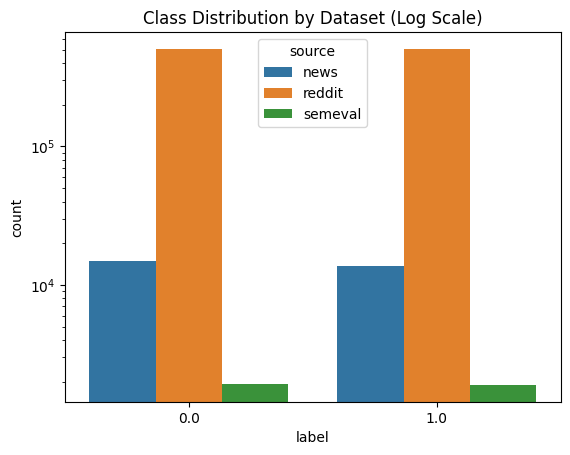

In [36]:
# CLass Distribution
sns.countplot(data=combined_df, x="label", hue="source")
plt.yscale("log")   # log scale
plt.title("Class Distribution by Dataset (Log Scale)")
plt.show()

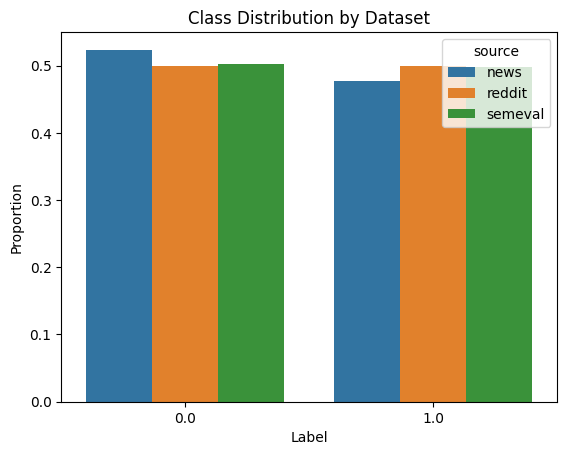

In [39]:
# CLass Distribution by Percentage
dist = (
    combined_df
    .groupby(["source", "label"])
    .size()
    .reset_index(name="count")
)

# Normalize manually
dist["proportion"] = dist.groupby("source")["count"].transform(lambda x: x / x.sum())

sns.barplot(data=dist, x="label", y="proportion", hue="source")

plt.title("Class Distribution by Dataset")
plt.ylabel("Proportion")
plt.xlabel("Label")
plt.show()

The normalized class distribution shows that all datasets are approximately balanced between sarcastic and non-sarcastic classes. This ensures that model performance is not influenced by class imbalance, allowing us to focus on cross-domain generalization effects.

## Class Distribution Analysis

The class distribution plot (normalized) shows that all three datasets—News Headlines, Reddit, and SemEval—are **approximately balanced** between sarcastic (1) and non-sarcastic (0) labels.

Although the datasets differ significantly in size:
- Reddit contains **over 500,000 samples per class**
- News contains around **25,000–30,000 samples per class**
- SemEval contains a much smaller number of samples (a few thousand)

the normalization allows us to compare **relative class proportions** rather than absolute counts.

### Key Insights:
- All datasets are **well balanced**, with label distributions close to 50/50.
- There is **no significant class imbalance**, ensuring fair training and evaluation within each dataset.
- The differences observed in model performance are therefore **unlikely to be caused by label bias**.

### Implication for This Project:
Since the goal is **cross-dataset generalization**:
- A model trained on Reddit may benefit from **large-scale and diverse data**
- A model trained on News may have **limited exposure**, potentially affecting performance on more complex datasets
- SemEval, being smaller but stylistically different, provides an **intermediate test domain**

### Experimental Importance:
Because all datasets are balanced, this setup allows us to isolate the effect of **domain differences**, enabling us to evaluate:

- How well sarcasm detection models **transfer across domains**
- Whether sarcasm patterns are **universal or dataset-specific**
- The extent of the **generalization gap** between different text sources

In [40]:
# Missing Values
combined_df.isnull().sum()

text      97168
label     97113
source        0
dtype: int64

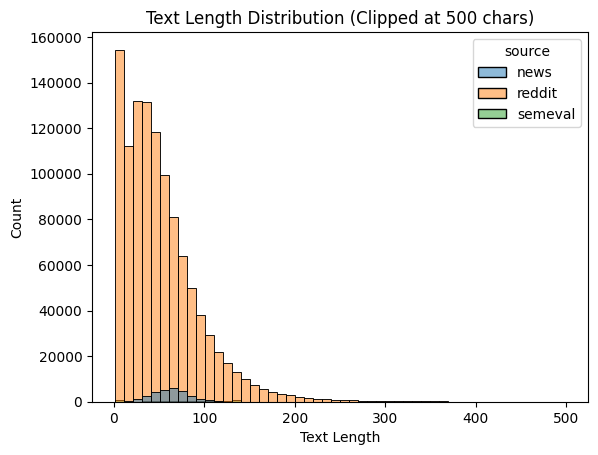

In [42]:
# Text Length Analysis
combined_df["text_length"] = combined_df["text"].astype(str).apply(len)

sns.histplot(
    data=combined_df[combined_df["text_length"] < 500],
    x="text_length",
    hue="source",
    bins=50
)

plt.title("Text Length Distribution (Clipped at 500 chars)")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.show()

Text(0.5, 1.05, 'Text Length Distribution per Dataset')

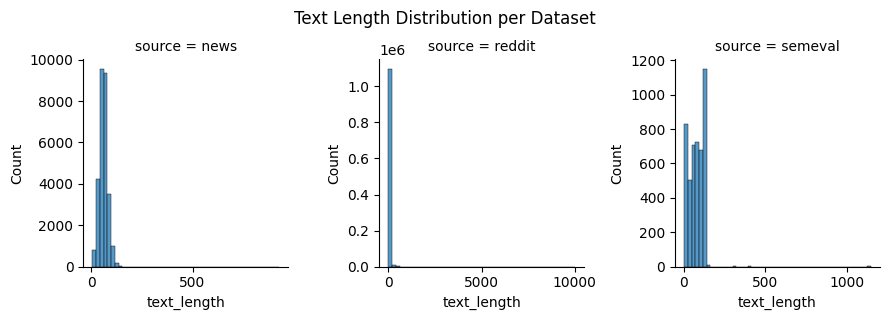

In [43]:
g = sns.FacetGrid(combined_df, col="source", sharex=False, sharey=False)
g.map(sns.histplot, "text_length", bins=50)

g.fig.suptitle("Text Length Distribution per Dataset", y=1.05)

## Text Length Analysis

The text length distribution varies significantly across datasets.

- **News headlines** are short and consistent, typically under 100 characters.
- **Reddit comments** are highly variable, ranging from very short replies to extremely long texts.
- **SemEval tweets** are relatively short, similar to news headlines, but slightly more variable.

To improve visualization, extreme outliers (primarily from Reddit) were clipped. This allows for a clearer comparison of the majority of samples.

### Key Insights:
- Reddit exhibits a **long-tail distribution**, with a small number of very long texts.
- News and SemEval are more **compact and consistent**.
- SemEval acts as an **intermediate domain** between News (structured) and Reddit (noisy and long-form).

### Implication:
- Models trained on News may struggle with long Reddit texts.
- Models trained on Reddit may generalize better to shorter texts.
- Text length differences contribute to the **domain shift** in this project.

In [45]:
# Sample Text Inspection

print("=== News (Sarcastic) ===")
print(news_df[news_df["label"] == 1]["text"].sample(5).values)

print("\n=== News (Non-Sarcastic) ===")
print(news_df[news_df["label"] == 0]["text"].sample(5).values)


print("\n=== Reddit (Sarcastic) ===")
print(reddit_df[reddit_df["label"] == 1]["text"].sample(5).values)

print("\n=== Reddit (Non-Sarcastic) ===")
print(reddit_df[reddit_df["label"] == 0]["text"].sample(5).values)


print("\n=== SemEval (Irony) ===")
print(semeval_df[semeval_df["label"] == 1]["text"].sample(5).values)

print("\n=== SemEval (Non-Irony) ===")
print(semeval_df[semeval_df["label"] == 0]["text"].sample(5).values)

=== News (Sarcastic) ===
["open floor plan increases office shooter's productivity by 95%"
 'single-engine cessna crashes into bush'
 'democratic candidate blows fundraising lead on massive 15-story lawn sign'
 'christian pornographer refuses to film sex tape for gay couple'
 "bruce springsteen concert totally changes area man's mind about voting"]

=== News (Non-Sarcastic) ===
["why runners can't stop talking about themselves"
 "ally sheedy knows you still think of her as an '80s basket case"
 "'no good deed' outpaces 'dolphin tale 2' at the box office"
 "iran's startups promise paradise for the country's unemployed youth"
 'earth day: a two-step strategy makes a sustainable difference']

=== Reddit (Sarcastic) ===
['Because most of reddit doesnt up/downvote'
 'You mean Sonys heavily guarded drm protected noise increasing camera algorithms amirite?'
 'Not many other indicators as well' 'You seem real fun to be around...'
 "Don't forget those 6 college football games a year."]

=== Red

## Sample Text Inspection and Qualitative Analysis

To better understand how sarcasm is expressed across datasets, we examine sample texts from each source.

### Observations:

- **News Headlines**:
  - Sarcasm is often **subtle and implicit**
  - Typically relies on **word choice and phrasing**
  - Texts are short and self-contained

- **Reddit Comments**:
  - Sarcasm is more **explicit and conversational**
  - Often includes **informal language, slang, and punctuation**
  - Frequently depends on **context or prior conversation**

- **SemEval Tweets**:
  - Sarcasm (and irony) is expressed using **short, informal text**
  - Common use of:
    - Hashtags (e.g., #sarcasm, #irony)
    - Mentions (@user)
    - Emojis
  - Often combines **brevity with expressive cues**
  - Some examples reflect **general irony rather than direct sarcasm**, highlighting differences in annotation criteria.


### Cross-Dataset Insight:

These observations highlight clear differences in how sarcasm (and irony) is expressed across datasets:

- News represents **formal, structured sarcasm**
- Reddit reflects **context-heavy, conversational sarcasm**
- SemEval introduces **short-form social media expressions and irony**

This reinforces the presence of both **domain variation** (text style, length, noise) and **task variation** (sarcasm vs irony).


### Key Challenges Identified:

- Sarcasm is **highly context-dependent**, especially in Reddit data.
- Many sarcastic texts are **ambiguous without external context**.
- Irony (in SemEval) may not always align with sarcasm, introducing **label ambiguity**.
- Similar words can appear in both sarcastic and non-sarcastic texts, making detection difficult.


### Implication for Modeling:

- Simple models (e.g., TF-IDF + SVM) may struggle with:
  - Implicit sarcasm
  - Context-dependent meaning
  - Distinguishing sarcasm from broader irony

- More advanced models (e.g., LSTM, BERT) may better capture:
  - Semantic relationships
  - Contextual cues
  - Tone and nuance across domains


### Key Insight:

Sarcasm and irony expression varies significantly across datasets, reinforcing the presence of both **domain-specific patterns** and **task variation**. This variability is expected to impact cross-dataset generalization performance and contribute to a measurable **generalization gap**.